In [4]:
!pip install kagglehub
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

# Download latest version of the dataset
dataset_path = kagglehub.dataset_download("mrkk8565/ship-classification")
print("Path to dataset files:", dataset_path)

TensorFlow version: 2.20.0
Using Colab cache for faster access to the 'ship-classification' dataset.
Path to dataset files: /kaggle/input/ship-classification


In [5]:
# Paths
TRAIN_DIR = os.path.join(dataset_path,'FGSC-23', 'train')
TEST_DIR  = os.path.join(dataset_path,'FGSC-23', 'test')

# Hyperparameters
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30

# Only include commercial or public/private ships
selected_classes = ['11', '14', '15', '16', '17', '18', '19', '20', '21', '22']
CLASS_NAMES = [
    'Medical Ship', 'Container Ship', 'Car Carrier', 'Hovercraft',
    'Bulk Carrier', 'Oil Tanker', 'Fishing Boat', 'Passenger Ship',
    'Liquefied Gas Ship', 'Barge'
]
NUM_CLASSES = len(selected_classes)

In [15]:
# Pure normalization for your Base Custom Model
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen  = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode='categorical',
    shuffle=False
)


Found 927 images belonging to 10 classes.
Found 238 images belonging to 10 classes.


## Custom Mo2bileNetV (Base Model)

In [18]:
print("--- Building Architecture 1: Mo2bileNetV ---")

# 1. Load pretrained MobileNetV2 base
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
mobilenet_base.trainable = False

# 2. Build model structure
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = mobilenet_base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenet = Model(inputs, outputs, name='MobileNetV2_Model')

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


--- Building Architecture 1: Mo2bileNetV ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
print('Training MobileNetV2...')
history_mobilenet = model_mobilenet.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks
)


Training MobileNetV2...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.3948 - loss: 2.0564 - val_accuracy: 0.5630 - val_loss: 1.4849 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.6419 - loss: 1.1421 - val_accuracy: 0.6387 - val_loss: 1.1420 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7325 - loss: 0.8441 - val_accuracy: 0.6807 - val_loss: 0.9603 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7843 - loss: 0.6880 - val_accuracy: 0.7353 - val_loss: 0.8329 - learning_rate: 0.0010
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8328 - loss: 0.5299 - val_accuracy: 0.7143 - val_loss: 0.7904 - learning_rate: 0.0010
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.8792 - loss: 0.4327 - val_accuracy: 0.7227 - val_loss: 0.8008 - learning_rate: 0.0010
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8878 -

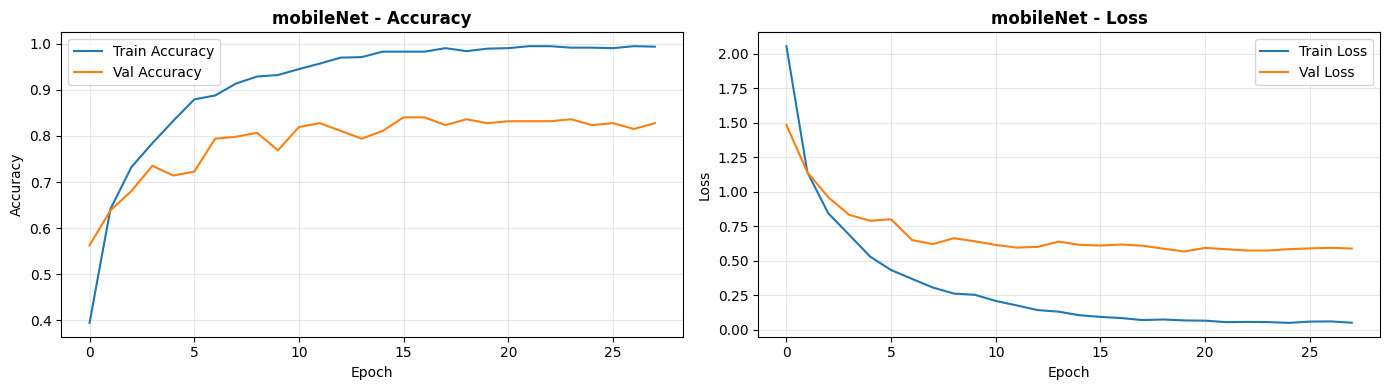

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step

MobileNet - Classification Report:
                    precision    recall  f1-score   support

      Medical Ship       0.83      1.00      0.91        10
    Container Ship       0.82      0.74      0.78        19
       Car Carrier       0.93      1.00      0.97        14
        Hovercraft       0.96      0.96      0.96        24
      Bulk Carrier       0.84      0.77      0.80        69
        Oil Tanker       0.81      0.88      0.84        33
      Fishing Boat       0.62      0.75      0.68        20
    Passenger Ship       0.62      0.56      0.59        18
Liquefied Gas Ship       0.95      0.95      0.95        20
             Barge       0.91      0.91      0.91        11

          accuracy                           0.83       238
         macro avg       0.83      0.85      0.84       238
      weighted avg       0.83      0.83      0.83       238



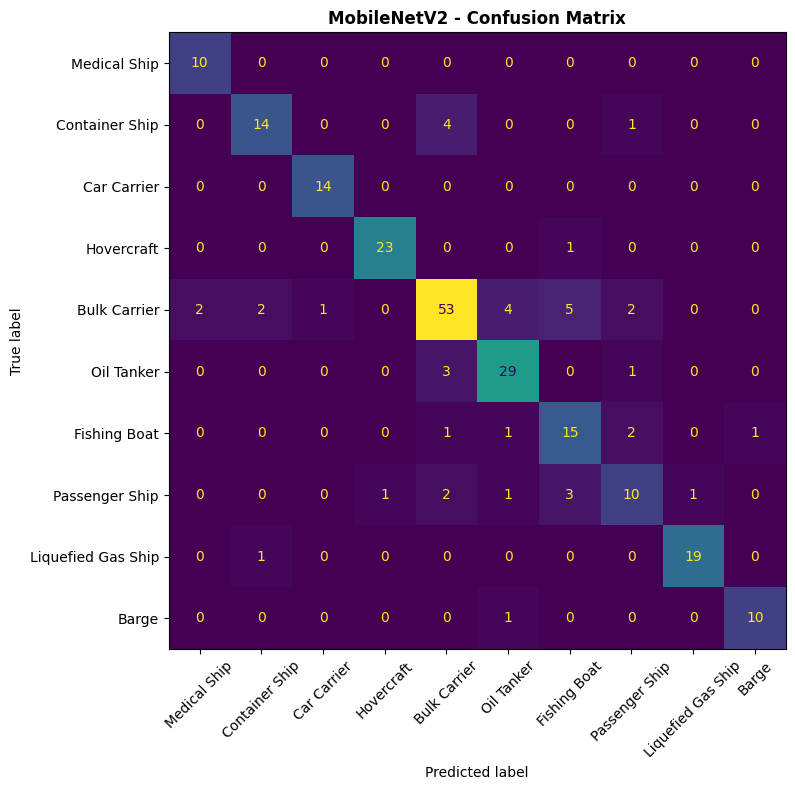

In [21]:
# Plot Custom CNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_mobilenet.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('mobileNet - Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mobilenet.history['loss'], label='Train Loss')
axes[1].plot(history_mobilenet.history['val_loss'], label='Val Loss')
axes[1].set_title('mobileNet - Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation and Classification Report
test_generator.reset()
cnn_pred_probs = model_mobilenet.predict(test_generator)

cnn_preds = np.argmax(cnn_pred_probs, axis=1)
true_classes = test_generator.classes

print("\nMobileNet - Classification Report:")
cnn_report_dict = classification_report(true_classes, cnn_preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
print(classification_report(true_classes, cnn_preds, target_names=CLASS_NAMES, zero_division=0))

# Confusion Matrix
cm_cnn = confusion_matrix(true_classes, cnn_preds)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 8))
disp_cnn.plot(ax=ax, xticks_rotation=45, colorbar=False)

# Updated Title to match your MobileNet model
ax.set_title('MobileNetV2 - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## ResNet50V2 (Transfer Learning)

In [25]:
print("--- Building Architecture 2: ResNet50V2 ---")

base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output, name='ResNet50V2')

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
resnet_model.summary()

--- Building Architecture 2: ResNet50V2 ---


Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,621,066 (93.92 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,565,824 (89.90 MB)

In [26]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Training ResNet50V2 Model...')
history_resnet = resnet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks  # Clean and fully managed by Keras!
)


Training ResNet50V2 Model...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 584ms/step - accuracy: 0.4272 - loss: 1.9829 - val_accuracy: 0.6891 - val_loss: 1.0192 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.6980 - loss: 0.9605 - val_accuracy: 0.7227 - val_loss: 0.8719 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.7659 - loss: 0.7149 - val_accuracy: 0.7605 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7918 - loss: 0.6122 - val_accuracy: 0.7563 - val_loss: 0.6804 - learning_rate: 0.0010
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8209 - loss: 0.5126 - val_accuracy: 0.7983 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.8533 - loss: 0.4595 - val_accuracy: 0.7899 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accur

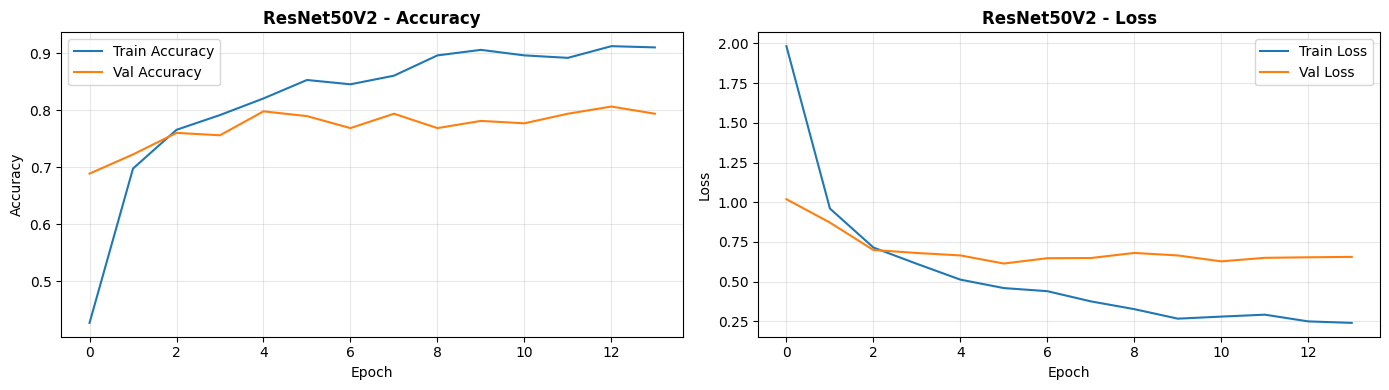

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 656ms/step

ResNet50V2 - Classification Report:
                    precision    recall  f1-score   support

      Medical Ship       1.00      0.80      0.89        10
    Container Ship       0.71      0.63      0.67        19
       Car Carrier       1.00      0.79      0.88        14
        Hovercraft       0.89      1.00      0.94        24
      Bulk Carrier       0.75      0.81      0.78        69
        Oil Tanker       0.71      0.73      0.72        33
      Fishing Boat       0.67      0.60      0.63        20
    Passenger Ship       0.65      0.61      0.63        18
Liquefied Gas Ship       1.00      1.00      1.00        20
             Barge       0.91      0.91      0.91        11

          accuracy                           0.79       238
         macro avg       0.83      0.79      0.80       238
      weighted avg       0.79      0.79      0.79       238



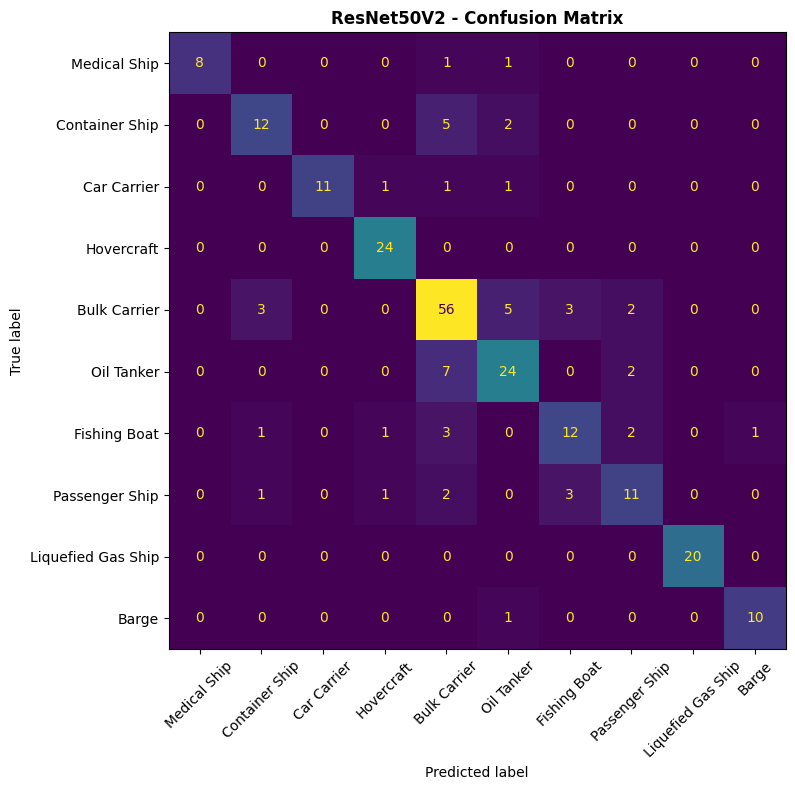

In [28]:
# 1. Plot ResNet50V2 Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_resnet.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_resnet.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('ResNet50V2 - Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_resnet.history['loss'], label='Train Loss')
axes[1].plot(history_resnet.history['val_loss'], label='Val Loss')
axes[1].set_title('ResNet50V2 - Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Evaluation and Classification Report
test_generator.reset()
resnet_pred_probs = resnet_model.predict(test_generator)
resnet_preds = np.argmax(resnet_pred_probs, axis=1)
true_classes = test_generator.classes

print("\nResNet50V2 - Classification Report:")
print(classification_report(true_classes, resnet_preds, target_names=CLASS_NAMES, zero_division=0))

# 3. Confusion Matrix Display
cm_resnet = confusion_matrix(true_classes, resnet_preds)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 8))
disp_resnet.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ResNet50V2 - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


## Performance Comparison

In [30]:
# 1. Evaluate MobileNetV2 Model
print("--- Evaluating MobileNetV2 ---")
test_generator.reset()
mobilenet_pred_probs = model_mobilenet.predict(test_generator)
mobilenet_preds = np.argmax(mobilenet_pred_probs, axis=1)
true_classes = test_generator.classes

# Generate MobileNet report dictionary
cnn_report_dict = classification_report(true_classes, mobilenet_preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)


# 2. Evaluate ResNet50V2 Model
print("\n--- Evaluating ResNet50V2 ---")
test_generator.reset()
resnet_pred_probs = resnet_model.predict(test_generator)
resnet_preds = np.argmax(resnet_pred_probs, axis=1)

# Generate ResNet report dictionary (Fixes the NameError!)
resnet_report_dict = classification_report(true_classes, resnet_preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

print("Evaluation complete! You can now run the Comparison Table cell.")


--- Evaluating MobileNetV2 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step

--- Evaluating ResNet50V2 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Evaluation complete! You can now run the Comparison Table cell.



===== Final Architecture Comparison Table =====
             Accuracy  Precision  Recall  F1-Score
Model                                             
MobileNetV2    0.8277     0.8295  0.8277    0.8267
ResNet50V2     0.7899     0.7922  0.7899    0.7887


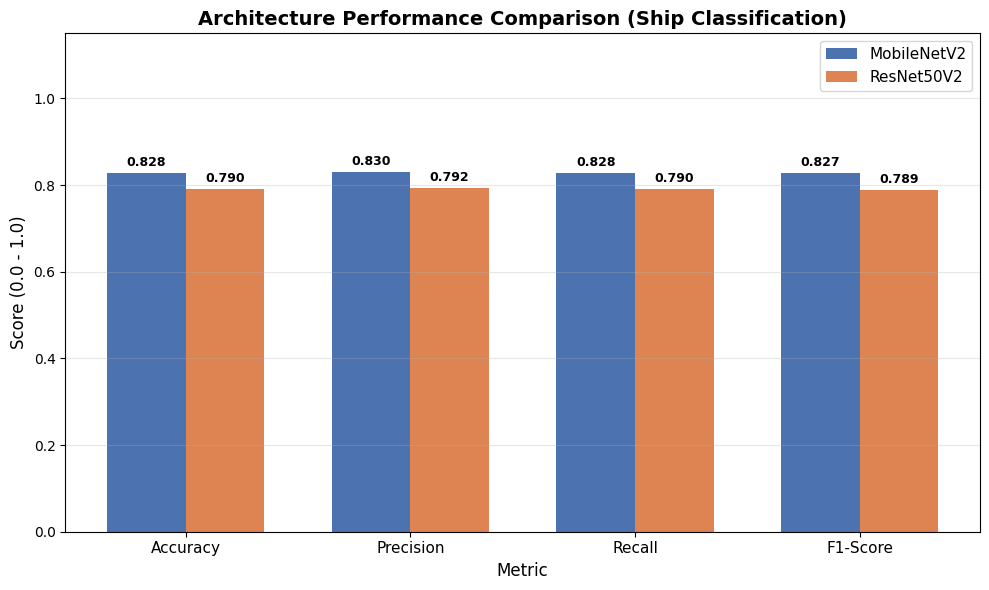

In [31]:
# Extract metrics for MobileNetV2 and ResNet50V2
results = {
    'Model': ['MobileNetV2', 'ResNet50V2'],
    'Accuracy': [cnn_report_dict['accuracy'], resnet_report_dict['accuracy']],
    'Precision': [cnn_report_dict['weighted avg']['precision'], resnet_report_dict['weighted avg']['precision']],
    'Recall': [cnn_report_dict['weighted avg']['recall'], resnet_report_dict['weighted avg']['recall']],
    'F1-Score': [cnn_report_dict['weighted avg']['f1-score'], resnet_report_dict['weighted avg']['f1-score']]
}

# Create a clean DataFrame
df_results = pd.DataFrame(results).set_index('Model').round(4)
print('\n===== Final Architecture Comparison Table =====')
print(df_results.to_string())

# Define metrics for the chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_list))
w = 0.35

# Plot side-by-side bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, df_results.loc['MobileNetV2'].values, w, label='MobileNetV2', color='#4C72B0')
bars2 = ax.bar(x + w/2, df_results.loc['ResNet50V2'].values, w, label='ResNet50V2', color='#DD8452')

# Styling the plot
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (0.0 - 1.0)', fontsize=12)
ax.set_title('Architecture Performance Comparison (Ship Classification)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.15)  # Slight headroom for labels
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add score labels on top of each bar
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## Inference - Test Image Prediction

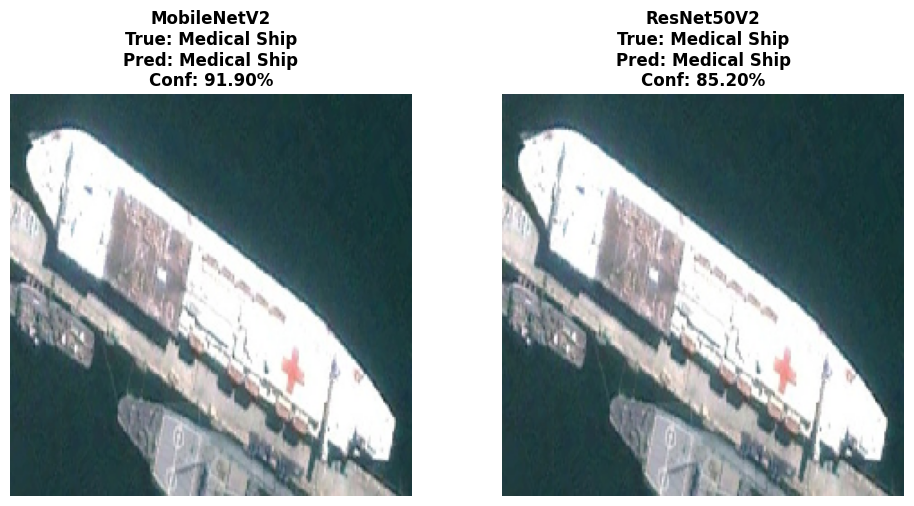

In [32]:
# Pick a random test image from the generator
test_generator.reset()
batch_images, batch_labels = next(test_generator)

# Select the first image in the batch
sample_img = batch_images[0]
true_label_idx = np.argmax(batch_labels[0])
true_label_name = CLASS_NAMES[true_label_idx]

# Predict with MobileNetV2 (Updated from cnn_model to model_mobilenet)
mobilenet_pred = model_mobilenet.predict(np.expand_dims(sample_img, axis=0), verbose=0)
mobilenet_pred_idx = np.argmax(mobilenet_pred[0])
mobilenet_pred_conf = mobilenet_pred[0][mobilenet_pred_idx]
mobilenet_pred_name = CLASS_NAMES[mobilenet_pred_idx]

# Predict with ResNet50V2
resnet_pred = resnet_model.predict(np.expand_dims(sample_img, axis=0), verbose=0)
resnet_pred_idx = np.argmax(resnet_pred[0])
resnet_pred_conf = resnet_pred[0][resnet_pred_idx]
resnet_pred_name = CLASS_NAMES[resnet_pred_idx]

# Display side-by-side visual inference results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display for MobileNetV2
axes[0].imshow(sample_img)
axes[0].set_title(f"MobileNetV2\nTrue: {true_label_name}\nPred: {mobilenet_pred_name}\nConf: {mobilenet_pred_conf:.2%}", fontweight='bold')
axes[0].axis('off')

# Display for ResNet50V2
axes[1].imshow(sample_img)
axes[1].set_title(f"ResNet50V2\nTrue: {true_label_name}\nPred: {resnet_pred_name}\nConf: {resnet_pred_conf:.2%}", fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
